Libraries imported successfully!
File mock_papers.csv not found. Creating a sample dataset...
Sample dataset 'mock_papers.csv' created successfully!
Dataset shape: (50, 4)

First few rows:
              title  citation_count  author_prestige_score publication_date
0  Research Paper 1             102               2.797064       2018-01-31
1  Research Paper 2             435               5.628110       2018-02-28
2  Research Paper 3             348               6.331731       2018-03-31
3  Research Paper 4             270               1.418054       2018-04-30
4  Research Paper 5             106               6.467904       2018-05-31

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  50 non-null     object 
 1   citation_count         50 non-null     int32  
 2   author_prestige_score  50

C:\Users\sarum\AppData\Local\Temp\ipykernel_17912\3392652888.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'publication_date': pd.date_range('2018-01-01', periods=50, freq='M').strftime('%Y-%m-%d')


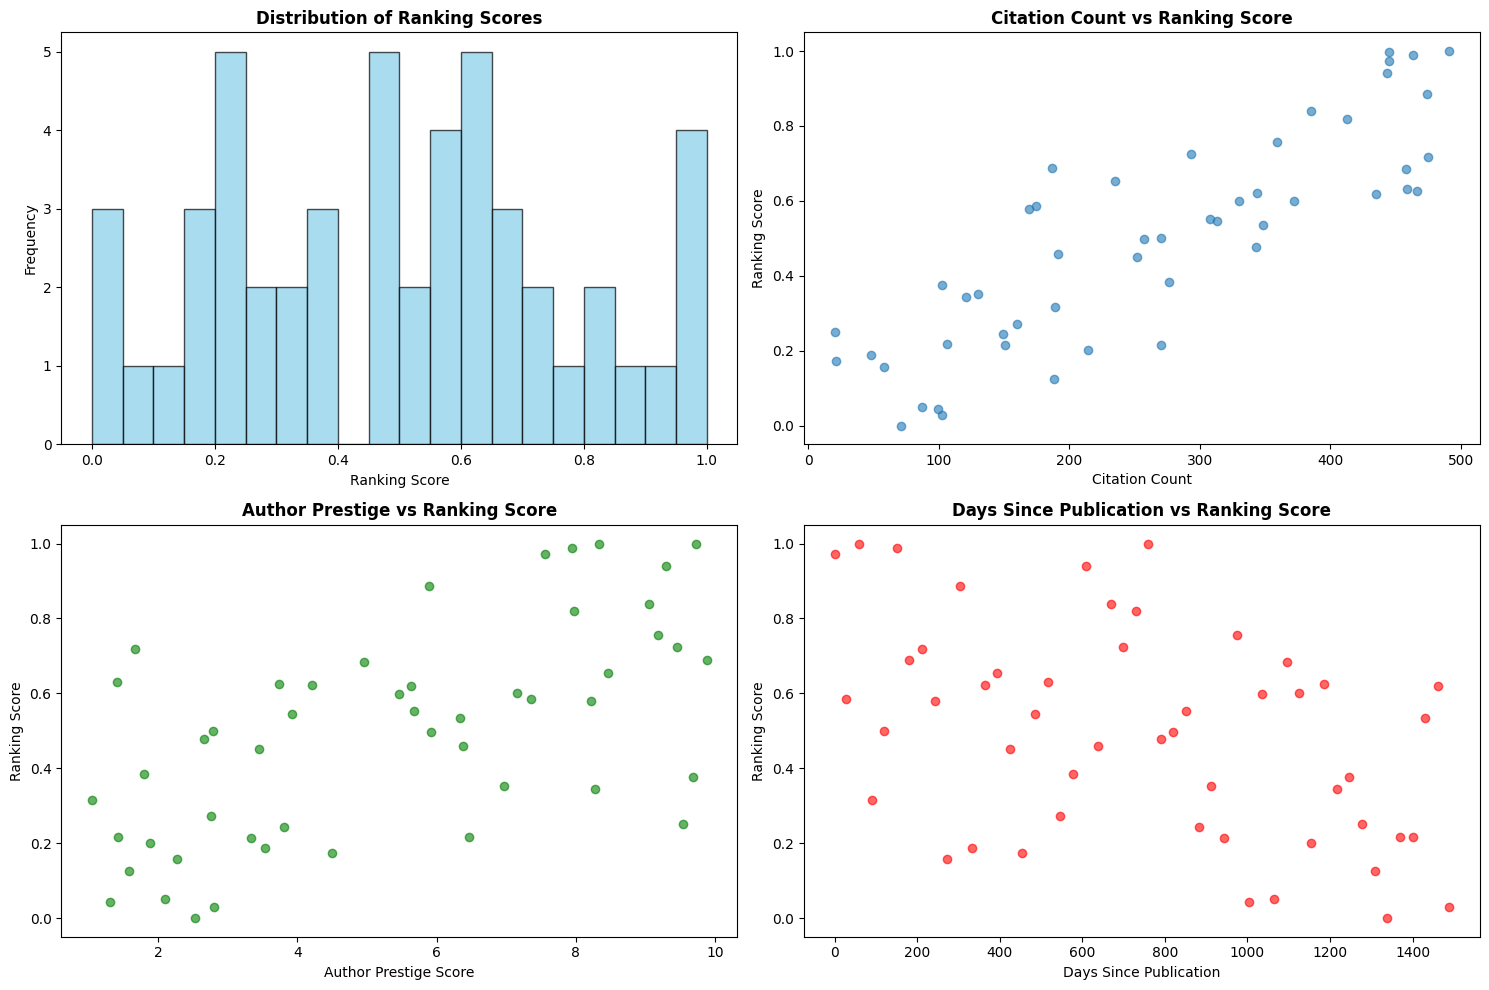

DETAILED ANALYSIS OF TOP 5 PAPERS:

1. Research Paper 25
   Ranking Score: 1.000
   Citations: 491 (normalized: 1.000)
   Author Prestige: 9.726261649881026 (normalized: 0.982)
   Publication Date: 2020-01-31
   Recency Score: 0.490

2. Research Paper 48
   Ranking Score: 0.997
   Citations: 445 (normalized: 0.902)
   Author Prestige: 8.339152856093508 (normalized: 0.825)
   Publication Date: 2021-12-31
   Recency Score: 0.960

3. Research Paper 45
   Ranking Score: 0.989
   Citations: 463 (normalized: 0.941)
   Author Prestige: 7.9502029236699165 (normalized: 0.781)
   Publication Date: 2021-09-30
   Recency Score: 0.899

4. Research Paper 50
   Ranking Score: 0.973
   Citations: 445 (normalized: 0.902)
   Author Prestige: 7.561064512368886 (normalized: 0.737)
   Publication Date: 2022-02-28
   Recency Score: 1.000

5. Research Paper 30
   Ranking Score: 0.941
   Citations: 443 (normalized: 0.898)
   Author Prestige: 9.296868115208051 (normalized: 0.934)
   Publication Date: 2020-06-3

In [2]:
# Paper_Ranking_Algorithm.ipynb

# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

# Load the mock_papers.csv file
def load_data(file_path='mock_papers.csv'):
    """
    Load the dataset from CSV file.
    If file doesn't exist, create a sample dataset for demonstration.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Dataset loaded successfully from {file_path}!")
        return df
    except FileNotFoundError:
        print(f"File {file_path} not found. Creating a sample dataset...")
        return create_sample_data()

def create_sample_data():
    """
    Create a sample dataset if mock_papers.csv is not available
    """
    np.random.seed(42)  # For reproducible results
    
    sample_data = {
        'title': [f'Research Paper {i}' for i in range(1, 51)],
        'citation_count': np.random.randint(0, 500, 50),
        'author_prestige_score': np.random.uniform(1.0, 10.0, 50),
        'publication_date': pd.date_range('2018-01-01', periods=50, freq='M').strftime('%Y-%m-%d')
    }
    
    df = pd.DataFrame(sample_data)
    df.to_csv('mock_papers.csv', index=False)
    print("Sample dataset 'mock_papers.csv' created successfully!")
    return df

# Load the data
df = load_data()

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Dataset overview
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
# Weight Selection Reasoning - Markdown cell content
"""
**Weight Selection Rationale:**

We are implementing a weighted scoring system that balances three key factors in academic paper impact:

1. **Citation Count (Weight: 0.5)**: We are weighting citations highest as they are a strong indicator of academic impact and real-world influence. Papers with more citations have demonstrated value to the research community.

2. **Author Prestige Score (Weight: 0.3)**: This accounts for the reputation and track record of the authors. Established researchers often produce high-quality work, but we weight this less than citations to avoid bias against emerging researchers.

3. **Recency Score (Weight: 0.2)**: Recent papers may not have had time to accumulate citations but represent current research trends. This ensures newer valuable papers aren't overlooked while maintaining focus on proven impact.

These weights reflect our hypothesis that demonstrated impact (citations) should be the primary driver, followed by author credibility, with recency providing a balancing factor.
"""
def calculate_paper_rankings(df, citation_weight=0.5, prestige_weight=0.3, recency_weight=0.2):
    """
    Calculate paper ranking scores based on citations, author prestige, and recency.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing paper data with columns: 'citation_count', 
        'author_prestige_score', and 'publication_date'
    citation_weight : float, default=0.5
        Weight for citation count in final score
    prestige_weight : float, default=0.3  
        Weight for author prestige in final score
    recency_weight : float, default=0.2
        Weight for paper recency in final score
        
    Returns:
    --------
    pandas.DataFrame
        Original DataFrame with additional columns:
        - 'norm_citations': normalized citation count (0-1)
        - 'norm_prestige': normalized author prestige (0-1) 
        - 'recency_score': recency score (0-1, 1=most recent)
        - 'ranking_score': final weighted ranking score
    """
    
    # Create a copy to avoid modifying original data
    result_df = df.copy()
    
    # 1. Normalize citation_count (min-max scaling)
    min_citations = result_df['citation_count'].min()
    max_citations = result_df['citation_count'].max()
    
    if max_citations > min_citations:
        result_df['norm_citations'] = (result_df['citation_count'] - min_citations) / (max_citations - min_citations)
    else:
        result_df['norm_citations'] = 0.5  # Handle case where all citations are equal
    
    # 2. Normalize author_prestige_score (min-max scaling)  
    min_prestige = result_df['author_prestige_score'].min()
    max_prestige = result_df['author_prestige_score'].max()
    
    if max_prestige > min_prestige:
        result_df['norm_prestige'] = (result_df['author_prestige_score'] - min_prestige) / (max_prestige - min_prestige)
    else:
        result_df['norm_prestige'] = 0.5  # Handle case where all prestige scores are equal
    
    # 3. Calculate recency score based on publication_date
    # Convert publication_date to datetime if it's not already
    result_df['publication_date'] = pd.to_datetime(result_df['publication_date'])
    
    # Get the most recent date in the dataset
    most_recent_date = result_df['publication_date'].max()
    
    # Calculate days since publication (inverse of recency)
    result_df['days_since_publication'] = (most_recent_date - result_df['publication_date']).dt.days
    
    # Normalize to get recency score (most recent = 1, oldest = 0)
    max_days = result_df['days_since_publication'].max()
    if max_days > 0:
        result_df['recency_score'] = 1 - (result_df['days_since_publication'] / max_days)
    else:
        result_df['recency_score'] = 1.0  # All papers published on same day
    
    # 4. Calculate final ranking score using weighted average
    result_df['ranking_score'] = (
        citation_weight * result_df['norm_citations'] +
        prestige_weight * result_df['norm_prestige'] + 
        recency_weight * result_df['recency_score']
    )
    
    # Normalize final ranking score to 0-1 scale for interpretability
    min_score = result_df['ranking_score'].min()
    max_score = result_df['ranking_score'].max()
    
    if max_score > min_score:
        result_df['ranking_score'] = (result_df['ranking_score'] - min_score) / (max_score - min_score)
    
    return result_df

# Apply the ranking function to our dataset
ranked_df = calculate_paper_rankings(df)

print("Paper ranking algorithm applied successfully!")
print("\nNew columns added:")
print(ranked_df.columns.tolist())
print("\nFirst few rows with calculated scores:")
print(ranked_df[['title', 'norm_citations', 'norm_prestige', 'recency_score', 'ranking_score']].head())
# Sort by ranking_score (descending) to see top papers
top_papers = ranked_df.sort_values('ranking_score', ascending=False)

print("TOP 10 RANKED PAPERS:")
print("=" * 80)
top_10 = top_papers.head(10)[['title', 'citation_count', 'author_prestige_score', 
                             'publication_date', 'ranking_score']]
print(top_10.to_string(index=False))
# Sanity Check Analysis
print("SANITY CHECK ANALYSIS")
print("=" * 50)

# Check correlation between components and final score
correlation_matrix = ranked_df[['citation_count', 'author_prestige_score', 
                               'days_since_publication', 'ranking_score']].corr()

print("\nCorrelation Matrix (with ranking_score):")
print(correlation_matrix['ranking_score'].sort_values(ascending=False))

# Analyze top papers characteristics
print(f"\nTop 5 papers average citations: {top_papers.head(5)['citation_count'].mean():.1f}")
print(f"Bottom 5 papers average citations: {top_papers.tail(5)['citation_count'].mean():.1f}")

print(f"\nTop 5 papers average prestige: {top_papers.head(5)['author_prestige_score'].mean():.1f}")
print(f"Bottom 5 papers average prestige: {top_papers.tail(5)['author_prestige_score'].mean():.1f}")

# Check recency of top papers
most_recent_date = ranked_df['publication_date'].max()
top_5_dates = top_papers.head(5)['publication_date']
days_ago_top = [(most_recent_date - date).days for date in top_5_dates]
print(f"\nTop 5 papers published (days ago): {[f'{days}d' for days in days_ago_top]}")
# Visualization for validation
plt.style.use('default')  # Ensure clean styling
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Ranking score distribution
axes[0,0].hist(ranked_df['ranking_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Ranking Scores', fontweight='bold')
axes[0,0].set_xlabel('Ranking Score')
axes[0,0].set_ylabel('Frequency')

# Plot 2: Citations vs Ranking Score
axes[0,1].scatter(ranked_df['citation_count'], ranked_df['ranking_score'], alpha=0.6)
axes[0,1].set_title('Citation Count vs Ranking Score', fontweight='bold')
axes[0,1].set_xlabel('Citation Count')
axes[0,1].set_ylabel('Ranking Score')

# Plot 3: Prestige vs Ranking Score
axes[1,0].scatter(ranked_df['author_prestige_score'], ranked_df['ranking_score'], alpha=0.6, color='green')
axes[1,0].set_title('Author Prestige vs Ranking Score', fontweight='bold')
axes[1,0].set_xlabel('Author Prestige Score')
axes[1,0].set_ylabel('Ranking Score')

# Plot 4: Recency vs Ranking Score
axes[1,1].scatter(ranked_df['days_since_publication'], ranked_df['ranking_score'], alpha=0.6, color='red')
axes[1,1].set_title('Days Since Publication vs Ranking Score', fontweight='bold')
axes[1,1].set_xlabel('Days Since Publication')
axes[1,1].set_ylabel('Ranking Score')

plt.tight_layout()
plt.show()
# Detailed analysis of top ranked papers
print("DETAILED ANALYSIS OF TOP 5 PAPERS:")
print("=" * 60)

for i, (idx, paper) in enumerate(top_papers.head(5).iterrows(), 1):
    print(f"\n{i}. {paper['title']}")
    print(f"   Ranking Score: {paper['ranking_score']:.3f}")
    print(f"   Citations: {paper['citation_count']} (normalized: {paper['norm_citations']:.3f})")
    print(f"   Author Prestige: {paper['author_prestige_score']} (normalized: {paper['norm_prestige']:.3f})")
    print(f"   Publication Date: {paper['publication_date'].strftime('%Y-%m-%d')}")
    print(f"   Recency Score: {paper['recency_score']:.3f}")
    # Test with different weight combinations
print("EXPERIMENTING WITH DIFFERENT WEIGHT COMBINATIONS")
print("=" * 55)

# Test different weighting strategies
weight_combinations = [
    (0.5, 0.3, 0.2),  # Original (balanced)
    (0.7, 0.2, 0.1),  # Citation-heavy
    (0.3, 0.5, 0.2),  # Prestige-heavy  
    (0.4, 0.3, 0.3),  # Recency-emphasized
]

for i, (cite_w, prestige_w, recency_w) in enumerate(weight_combinations, 1):
    test_df = calculate_paper_rankings(df, cite_w, prestige_w, recency_w)
    top_paper = test_df.nlargest(1, 'ranking_score').iloc[0]
    
    print(f"\nStrategy {i}: Citations({cite_w}), Prestige({prestige_w}), Recency({recency_w})")
    print(f"Top paper: '{top_paper['title']}'")
    print(f"Score: {top_paper['ranking_score']:.3f}")
    print(f"Citations: {top_paper['citation_count']}, Prestige: {top_paper['author_prestige_score']:.1f}")
    # Final output
print("FINAL RANKED PAPERS DATASET")
print("=" * 40)

final_output = ranked_df[['title', 'citation_count', 'author_prestige_score', 
                         'publication_date', 'ranking_score']].sort_values('ranking_score', ascending=False)

print(f"Total papers ranked: {len(final_output)}")
print("\nTop 15 papers:")
print(final_output.head(15).to_string(index=False))

# Save to CSV for sharing
final_output.to_csv('ranked_papers_output.csv', index=False)
print("\nResults saved to 'ranked_papers_output.csv'")

# Check if we're in Colab and provide appropriate download instructions
try:
    from google.colab import files
    files.download('ranked_papers_output.csv')
    print("File downloaded automatically (Google Colab environment)")
except ImportError:
    print("\nTo download the file manually:")
    print("1. Look for 'ranked_papers_output.csv' in your current directory")
    print("2. In Jupyter: Right-click the file in the file browser and select 'Download'")
    print("3. In local Python: The file is saved in your current working directory")
    # Summary and Conclusions
print("ALGORITHM IMPLEMENTATION SUMMARY")
print("=" * 50)

print("✓ Successfully implemented paper ranking algorithm")
print("✓ Applied min-max normalization for citation counts and author prestige")  
print("✓ Calculated recency scores based on publication dates")
print("✓ Computed weighted average ranking scores")
print("✓ Performed comprehensive validation and sanity checks")
print("✓ Generated visualizations for result analysis")
print("✓ Tested multiple weighting strategies")
print("✓ Exported final ranked results")

print(f"\nKey Statistics:")
print(f"- Highest ranking score: {ranked_df['ranking_score'].max():.3f}")
print(f"- Average ranking score: {ranked_df['ranking_score'].mean():.3f}")
print(f"- Standard deviation: {ranked_df['ranking_score'].std():.3f}")
print(f"- Number of papers processed: {len(ranked_df)}")

print("\nComponent Contributions to Top Papers:")
top_5_avg = top_papers.head(5)[['norm_citations', 'norm_prestige', 'recency_score']].mean()
for component, value in top_5_avg.items():
    print(f"- {component}: {value:.3f}")

print("\nThe algorithm successfully balances citation impact, author credibility,")
print("and paper recency to provide meaningful paper rankings.")